In [6]:
# Import pandas for data manipulation and analysis

import pandas as pd

In [7]:
# Set the working directory to the project folder

import os

os.chdir(r"C:\Users\Kaith\Desktop\Credit_Card_Fraud_Detection\Datasets")

In [8]:
# Confirm the current working directory and list the files

print(os.getcwd())
print(os.listdir())

C:\Users\Kaith\Desktop\Credit_Card_Fraud_Detection\Datasets
['credit_card_fraud_10k.csv']


In [9]:
# Load the credit_card_fraud_10 dataset

df = pd.read_csv("credit_card_fraud_10k.csv")

## DATA INSPECTION

In [10]:
# Display the first five records to understand the dataset structure

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [11]:
# Check the number of rows and columns in the dataset

df.shape

(10000, 10)

In [12]:
# Check column names, non-null values, and datatypes

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [13]:
# Check the number of missing values in each column

df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [14]:
# Check the number of duplicate records in the dataset

df.duplicated().sum()

np.int64(0)

In [15]:
# Generate descriptive statistics for the numerical columns

df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [16]:
# Count the number of the transactions in each merchant category

df['merchant_category'].value_counts()

merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64

In [17]:
# Count the number of fraudulent and legitimate transactions

df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [18]:
# Calculate the percentage of fraudulent and non-fraudulent transactions

fraud_percentage = df['is_fraud'].value_counts(normalize=True) * 100
print(fraud_percentage)

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


In [19]:
# Display fraud and non-fraud percentages clearly

fraud_percentage = (df['is_fraud'].value_counts(normalize=True).mul(100).round(2))

print("Transaction Class Distribution (%):")
print(fraud_percentage)

Transaction Class Distribution (%):
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


In [20]:
# Calculate and display the percentage of fraudulent transactions

fraud_rate = df['is_fraud'].mean() * 100

print(f"Fraudulent transactions: {fraud_rate:.2f}%")
print(f"Non-fraudulent transactions: {100 - fraud_rate:.2f}%")

Fraudulent transactions: 1.51%
Non-fraudulent transactions: 98.49%


In [59]:
# Count the number of domestic and foreign transactions

df['foreign_transaction'].value_counts()

foreign_transaction
0    9022
1     978
Name: count, dtype: int64

In [60]:
# Count the number of transactions with and without a location mismatch

df['location_mismatch'].value_counts()

location_mismatch
0    9143
1     857
Name: count, dtype: int64

In [22]:
# Count transactions for each hour and display them in chronological order

df['transaction_hour'].value_counts().sort_index()

transaction_hour
0     417
1     425
2     385
3     425
4     384
5     419
6     413
7     425
8     424
9     426
10    358
11    385
12    417
13    420
14    458
15    432
16    421
17    429
18    439
19    421
20    419
21    423
22    416
23    419
Name: count, dtype: int64

### Data Inspection Summary

- The dataset contains **10,000 transactions and 10 columns.**
- Dataset structure and dimensions were examined.
- Data types and column information were checked.
- Missing values and duplicate records were assessed.
- Numerical statistics were reviewed.
- Categorical distributions were examined.
- Fraud class distribution was checked.
- Transaction-hour distribution was reviewed.

## DATA CLEANING

In [62]:
#  Confirm the data type of all column

df.dtypes

transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object

In [63]:
# Confirm the descriptive statistics of key numerical features

df[['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']].describe()

,amount,transaction_hour,device_trust_score,velocity_last_24h,cardholder_age
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.949849,11.593300,61.798900,2.008900,43.468700
std,175.392827,6.922708,21.487053,1.432559,14.979147
min,0.000000,0.000000,25.000000,0.000000,18.000000
25%,50.905000,6.000000,43.000000,1.000000,30.000000
50%,122.095000,12.000000,62.000000,2.000000,44.000000
75%,242.480000,18.000000,80.000000,3.000000,56.000000
max,1471.040000,23.000000,99.000000,9.000000,69.000000


In [64]:
# Confirm that transaction hours fall within the valid 0-23 range

df['transaction_hour'].min(),
df['transaction_hour'].max()

np.int64(23)

In [65]:
df['transaction_hour'].min()

np.int64(0)

In [66]:
# Confirm the min and max transaction amount

df['amount'].min()
df['amount'].max()

np.float64(1471.04)

In [67]:
df['amount'].min()

np.float64(0.0)

In [68]:
df['amount'].max()

np.float64(1471.04)

In [69]:
# Confirm whether any transactions have a zero amount

df[df['amount'] == 0].shape[0]

1

In [70]:
df[df['amount'] == 0]

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
2902,2903,0.0,16,Travel,0,0,72,1,23,0


In [71]:
# Confirm that device trust scores fall within the expected range

df['device_trust_score'].min(),
df['device_trust_score'].max()

np.int64(99)

In [72]:
df['device_trust_score'].min()

np.int64(25)

In [73]:
# Confirm the min and max transactions velocity in the last 24 hours

df['velocity_last_24h'].min(),
df['velocity_last_24h'].max()

np.int64(9)

In [74]:
df['velocity_last_24h'].min()

np.int64(0)

In [75]:
df['cardholder_age'].max()

np.int64(69)

In [76]:
df['cardholder_age'].min()

np.int64(18)

In [77]:
# Confirm the unique values in key transaction and fraud indicator columns

df[['foreign_transaction', 'location_mismatch', 'is_fraud']].apply(lambda x:x.unique())

,foreign_transaction,location_mismatch,is_fraud
0,0,0,0
1,1,1,1


In [78]:
# Confirm that transaction IDs are unique

df['transaction_id'].nunique()

10000

In [79]:
# Save the cleaned dataset as a new CSV file

df.to_csv("credit_card_fraud_cleaned.csv", index=False)

In [81]:
# Confirm that the cleaned dataset file was created

import os
os.path.exists("credit_card_fraud_cleaned.csv")

True

### Data Cleaning Summary

- **Data Quality:** The dataset was checked for missing values, duplicate records, and data type consistency. No missing values or duplicate records were identified.
- **Data Validation:** Numerical variables were reviewed and found to be within reasonable ranges. Binary variables contained only valid 0 and 1 values.
- **Transaction Validation:** One transaction with a zero transaction amount was identified. It was retained because there was insufficient evidence to classify it as an invalide record.
- **Uniqueness:** All 10,000 transaction IDs were unique, confirming that each transaction could be uniquely identified.
- **Final Assessment:**  No major data cleaning changes were required. The dataset was considered clean and ready for Exploratory Data Analysis(EDA).

## EXPLORATORY DATA ANALYSIS (EDA)

In [82]:
# Calculate the number of legitimate and fraudulent transactions

df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [84]:
# Calculate the percentage of legitimate and fraudulent transactions

fraud_percentage = df['is_fraud'].value_counts(normalize=True) * 100
fraud_percentage

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

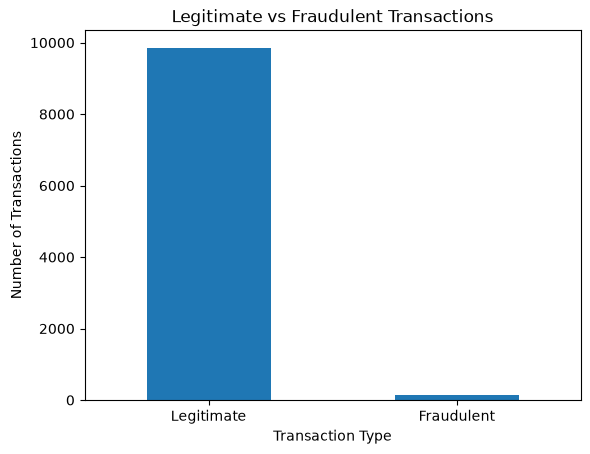

In [85]:
# Import Matplotlib for creating visualizations

import matplotlib.pyplot as plt

#Plot the number of legitimate and fraudulent transactions
df['is_fraud'].value_counts().plot (kind='bar')

# Add a title and axis labels
plt.title('Legitimate vs Fraudulent Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks([0,1], ['Legitimate', 'Fraudulent'], rotation=0)
plt.show()

In [87]:
# Calculate the total number of fraudulent transactions for each merchant category

fraud_by_merchant = df.groupby('merchant_category')['is_fraud'].sum()
fraud_by_merchant

merchant_category
Clothing       24
Electronics    24
Food           35
Grocery        39
Travel         29
Name: is_fraud, dtype: int64

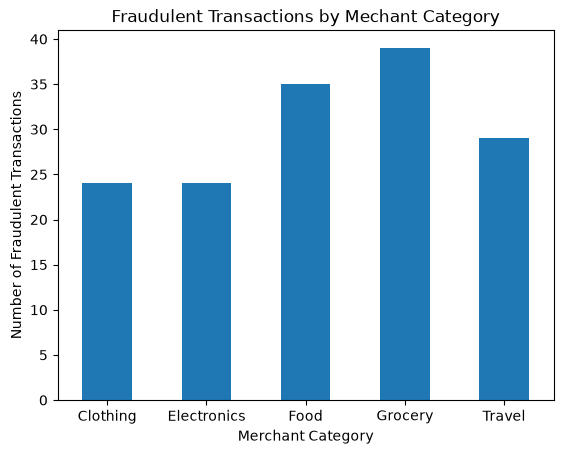

In [88]:
# Plot the number of fraudulent transactions by merchant category

fraud_by_merchant.plot(kind='bar')

plt.title('Fraudulent Transactions by Mechant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=0)
plt.show()

In [89]:
# Calculate the fraud rate for each merchant category

fraud_rate_by_merchant = df.groupby('merchant_category')['is_fraud'].mean() * 100
fraud_rate_by_merchant

merchant_category
Clothing       1.170732
Electronics    1.248050
Food           1.672241
Grocery        2.006173
Travel         1.457286
Name: is_fraud, dtype: float64

In [91]:
# Calculate the number of fraudulent transactions by foreign transaction status

fraud_by_foreign = df.groupby('foreign_transaction')['is_fraud'].sum()
fraud_by_foreign

foreign_transaction
0    69
1    82
Name: is_fraud, dtype: int64

In [92]:
# Calculate the fraud rate for foreign and domestic transactions

fraud_rate_by_foreign = df.groupby('foreign_transaction')['is_fraud'].mean() * 100
fraud_rate_by_foreign

foreign_transaction
0    0.764797
1    8.384458
Name: is_fraud, dtype: float64

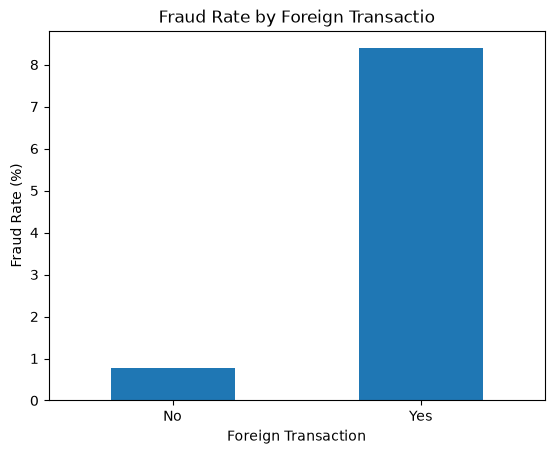

In [93]:
# Plot the number of fraudulent transactions by foreign

fraud_rate_by_foreign.plot(kind='bar')

plt.title('Fraud Rate by Foreign Transaction')
plt.xlabel('Foreign Transaction')
plt.ylabel('Fraud Rate (%)')
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.show()

In [95]:
# # Calculate the fraud rate by location mismatch status

fraud_rate_by_location = df.groupby('location_mismatch')['is_fraud'].mean() * 100
fraud_rate_by_location

location_mismatch
0    0.864049
1    8.401400
Name: is_fraud, dtype: float64

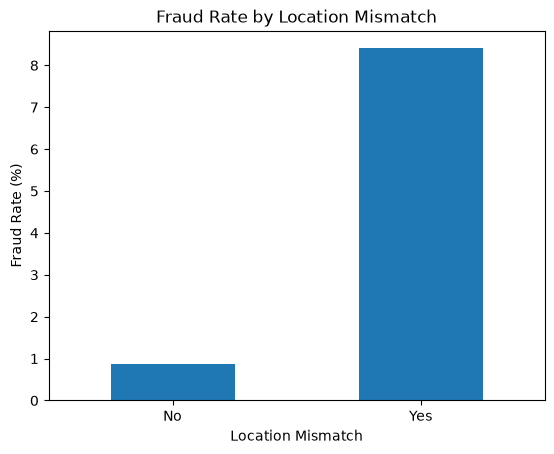

In [97]:
# Plot the fraud rate by location mismatch status

fraud_rate_by_location.plot(kind='bar')

plt.title('Fraud Rate by Location Mismatch')
plt.xlabel('Location Mismatch')
plt.ylabel('Fraud Rate (%)')
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.show()

In [98]:
# Calculate the average device trust score for fraudulent and legitimate transactions

df.groupby('is_fraud')['device_trust_score'].mean()

is_fraud
0    62.165804
1    37.867550
Name: device_trust_score, dtype: float64

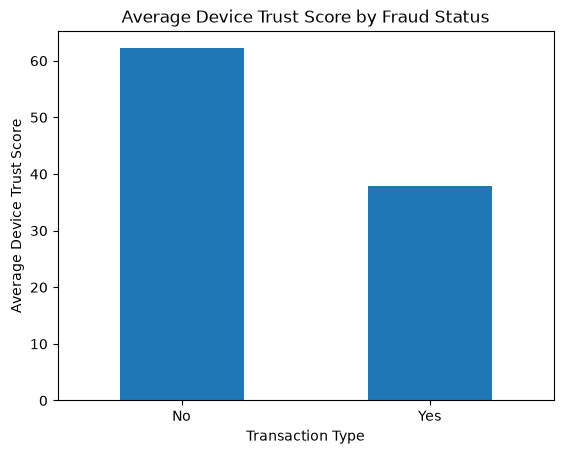

In [99]:
# Plot the average device trust score by fraud status

df.groupby('is_fraud')['device_trust_score'].mean().plot(kind='bar')

plt.title('Average Device Trust Score by Fraud Status')
plt.xlabel('Transaction Type')
plt.ylabel('Average Device Trust Score')
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.show()

In [100]:
# Calculate the average transaction amount for fraudulent and legitimate transactions

df.groupby('is_fraud')['amount'].mean()

is_fraud
0    175.333015
1    216.182980
Name: amount, dtype: float64

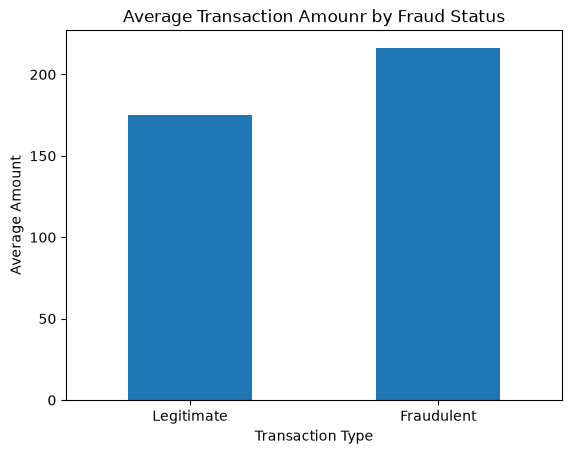

In [101]:
# Plot the average transaction amount by fraud status

df.groupby('is_fraud')['amount'].mean().plot(kind='bar')

plt.title('Average Transaction Amounr by Fraud Status')
plt.xlabel('Transaction Type')
plt.ylabel('Average Amount')
plt.xticks([0,1], ['Legitimate','Fraudulent'], rotation=0)
plt.show()

In [102]:
# Calculate the number of fraudulent transactions for each transaction hour

fraud_by_hour = df.groupby('transaction_hour')['is_fraud'].sum()
fraud_by_hour

transaction_hour
0     37
1     34
2     23
3     27
4      1
5      2
6      2
7      0
8      3
9      1
10     1
11     2
12     0
13     2
14     1
15     2
16     0
17     2
18     1
19     4
20     2
21     1
22     0
23     3
Name: is_fraud, dtype: int64

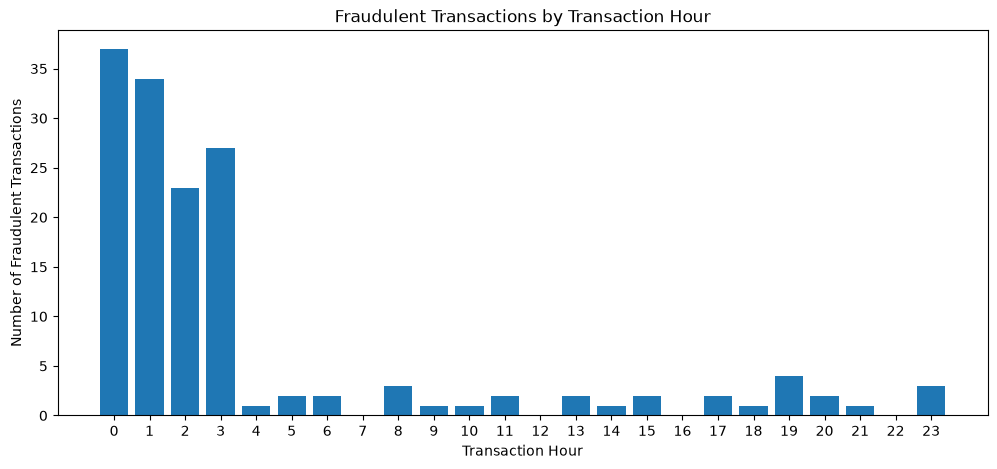

In [105]:
# Create a bar chart showing fraudulent transactions by transaction hour

plt.figure(figsize=(12, 5))

plt.bar(fraud_by_hour.index, fraud_by_hour.values)

plt.title('Fraudulent Transactions by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(24))
plt.show()

In [106]:
# Calculate the fraud rate for each transaction velocity level

fraud_rate_by_velocity = df.groupby('velocity_last_24h')['is_fraud'].mean() * 100
fraud_rate_by_velocity

velocity_last_24h
0     1.015965
1     0.779510
2     1.051841
3     1.176471
4     1.070664
5    11.506849
6     8.396947
7     9.523810
8     0.000000
9     0.000000
Name: is_fraud, dtype: float64

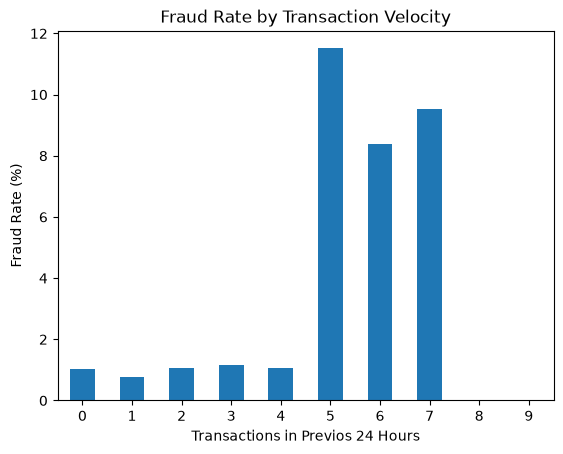

In [107]:
# Plot the fraud rate by transaction velocity

fraud_rate_by_velocity.plot(kind='bar')

plt.title('Fraud Rate by Transaction Velocity')
plt.xlabel('Transactions in Previos 24 Hours')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [108]:
# Create age group from cardholder age

df['age_group'] = pd.cut(df['cardholder_age'], bins=[17, 25, 35, 45, 55, 70], labels=['18-25', '26-35', '36-45', '46-55', '56-69'])

fraud_rate_by_age = df.groupby('age_group', observed=True)['is_fraud'].mean() * 100
fraud_rate_by_age

age_group
18-25    1.302083
26-35    1.600413
36-45    1.827676
46-55    1.389604
56-69    1.423754
Name: is_fraud, dtype: float64

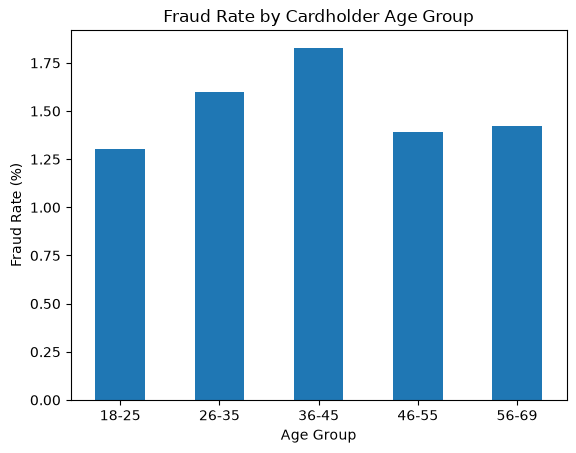

In [109]:
# Plot the fraud rate by cardholder age group

fraud_rate_by_age.plot(kind='bar')

plt.title('Fraud Rate by Cardholder Age Group')
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.show()

### EDA Summary

The exploratory analysis identified several important patterns in the credit card transaction data.
- Fraudulent transactions represented 1.51% of all transactions, confirming a strong class imbalance.
- Foreign transactions and transactions with a location mismatch showed higher fraud rates than thier respective counterparts. 
- Fraudulent transactions had a lower average device trust score and a higher average transaction amount than legitimate transactions.
- Fraud counts varied across merchant categories and transaction hours.
- Transaction velocity and cardholder age groups also showed differences in fraud rates.
- These findings provide useful indicators for the classification model and will be considered during the machine learning stage. 